In [1]:
import pandas as pd
import numpy as np

file_path = "data.xlsx"
xl = pd.ExcelFile(file_path, engine='openpyxl')

In [2]:
df_daur = pd.read_excel(file_path, sheet_name='DAUR PREPA 2025')
df_letudiant_inge = pd.read_excel(file_path, sheet_name ='LETUDIANT INGE')
df_letudiant_map = pd.read_excel(file_path, sheet_name = 'LETUDIANT MAPPING')
df_scei = pd.read_excel(file_path, sheet_name='SCEI 2024')
df_voeux_cpge = pd.read_excel(file_path, sheet_name='VOEUX > CPGE')

In [3]:
#Cleaning de letudiant

df_letudiant_inge.columns = (
    df_letudiant_inge.columns
    .str.replace('%', 'pct') 
)

df_letudiant_clean = df_letudiant_inge.dropna(subset=['Etablissement UAI'])

df_letudiant_inge_clean = df_letudiant_inge.drop(columns=[
    'Département',
    'Ville',
    'moyenne sur 20 au bac promo 2024',
    'url',
    '1 AN nb intégrés',
    '1 AN moy nationale', 
    'sur 5 ans nb de prépas classés',
    'sur 5 ans Moyenne nat intégration'])

#Cleaning de daur 
df_daur_clean = df_daur.dropna(subset=['UAI établissement'])


In [4]:
#On merge les dataset pour regrouper les features par prépa et par filières 
data = pd.merge(
df_letudiant_inge_clean, 
df_daur_clean[['UAI établissement','Filière', 'Note finale']],
left_on=['Etablissement UAI', 'Filière'],
right_on=['UAI établissement', 'Filière'],
how='inner')      
data.drop('UAI établissement', axis = 1, inplace=True)

In [5]:
simple_data = data[data['Panier'] == 'Polytechnique + ENS']
simple_data = simple_data.dropna()

In [6]:
simple_data.columns

Index(['Nom école', 'Etablissement UAI', 'Filière', 'Panier',
       '1 AN pct integration', '1 an total eleves',
       'sur 5 ans pct intégration', 'sur 5 ans rang dans classement',
       'Note finale'],
      dtype='object')

In [7]:
import algo as algo

### Génération d'une population pour évaluer le modèle 

In [8]:
"""
Je ne prétends pas dans cette section "valider" ou non mon modèle car je n'ai pas le temps (3h environ) pour le faire, j'ai uniquement 
l'intention d'avoir un bref apercu des résultats de la simulation et de les comparer avec la réalité 
"""

max_daur = simple_data['Note finale'].max()
min_daur = simple_data['Note finale'].min()

eleves = []

#création de la population d'élèves en parcourant les diff classes
for col, row in simple_data.iterrows():
    uai = row['Etablissement UAI']
    nom_prepa = row['Nom école']
    filiere = row['Filière']
    nb_eleve = row['1 an total eleves']
    p_1an = row['1 AN pct integration']
    p_5ans = row['sur 5 ans pct intégration']
    score_daur = row['Note finale']
    for rang in range (1,nb_eleve+1) :
        probas = algo.simulation_admission_proba(rang, p_1an, p_5ans, nb_eleve, score_daur, max_daur, min_daur)
        proba = np.mean(probas)
        admission = np.random.binomial(1, proba)
        eleve = {'uai':uai, 'nom_prepa':nom_prepa, 'filiere':filiere, 'admission':admission, 'p_5_ans': p_5ans, 'rang':rang}
        eleves.append(eleve)

df_eleves = pd.DataFrame(eleves)

c:\Users\arthu\Documents\Projets\code_edumapper\algo.py:6: RuntimeWarning: overflow encountered in exp
  return L / (1 + np.exp(a*(k-r0)))
c:\Users\arthu\Documents\Projets\code_edumapper\algo.py:15: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  sol = fsolve(objective, x0=0.5, maxfev=40)                    #fsolve utilise une variante de la méthode hybride de Powell
c:\Users\arthu\Documents\Projets\code_edumapper\algo.py:15: RuntimeWarning: The number of calls to function has reached maxfev = 40.
  sol = fsolve(objective, x0=0.5, maxfev=40)                    #fsolve utilise une variante de la méthode hybride de Powell
c:\Users\arthu\Documents\Projets\code_edumapper\algo.py:15: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last five Jacobian evaluations.
  sol = fsolve(objective, x0=0.5, maxfev=40)                    #fsolve utilise une variante de la méth

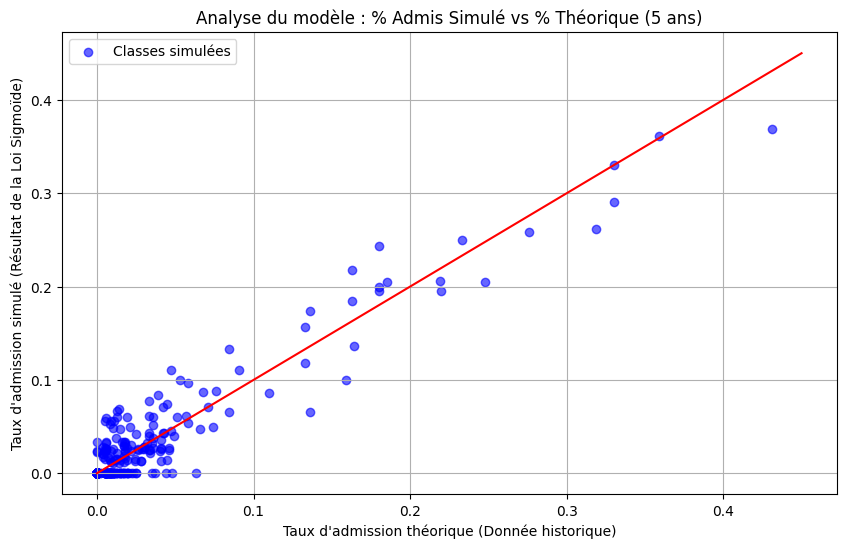

In [9]:
#vérification pourcentage admis par classe pour vérifier la cohérence du modèle
import matplotlib.pyplot as plt

df_analyse = df_eleves.groupby(['uai', 'filiere']).agg({'p_5_ans': 'first', 'admission': 'mean'}).reset_index()
df_analyse = df_analyse.rename(columns={'admission': 'p_simule'})


plt.figure(figsize=(10, 6))
plt.scatter(df_analyse['p_5_ans'], df_analyse['p_simule'], color='blue', alpha=0.6, label='Classes simulées')

plt.plot([0, 0.45], [0, 0.45], color='red')

plt.title('Analyse du modèle : % Admis Simulé vs % Théorique (5 ans)')
plt.xlabel('Taux d\'admission théorique (Donnée historique)')
plt.ylabel('Taux d\'admission simulé (Résultat de la Loi Sigmoïde)')
plt.grid(True, which='both')
plt.legend()
plt.show()

In [10]:
print("Filières détectées :", df_eleves['filiere'].unique())
print("Exemples de lycées :", df_eleves['nom_prepa'].unique()[:10])

Filières détectées : ['MP' 'PC' 'PSI' 'PT']
Exemples de lycées : ['Lalande' 'Masséna' 'Stanislas' 'Centre International Valbonne'
 'Chrestien-de-Troyes' 'Ferdinand-Foch' 'Cézanne' 'Thiers'
 'Notre-Dame-de-Sion' 'Malherbe']


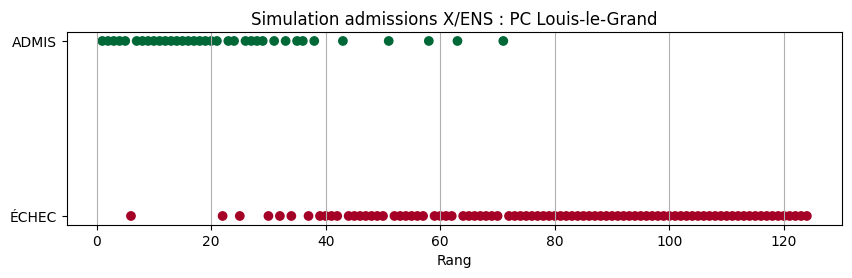

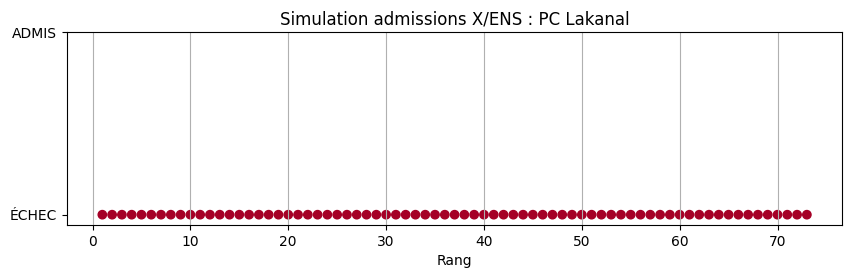

In [11]:
llg_pc = df_eleves[(df_eleves['nom_prepa'].str.contains('Louis-Le-Grand', case=False, na=False)) &  #gestion des string un peu embetant
                   (df_eleves['filiere'].str.contains('PC', case=False, na=False))
].sort_values('rang')

lakanal_pc = df_eleves[(df_eleves['nom_prepa'].str.contains('Lakanal', case=False, na=False)) & 
                    (df_eleves['filiere'].str.contains('PC', case=False, na=False))
].sort_values('rang')


plt.figure(figsize=(10, 2.5))
plt.scatter(llg_pc['rang'], llg_pc['admission'], c=llg_pc['admission'], cmap='RdYlGn')
plt.yticks([0, 1], ['ÉCHEC', 'ADMIS'])
plt.title("Simulation admissions X/ENS : PC Louis-le-Grand")
plt.xlabel("Rang")
plt.grid(axis='x')
plt.show()

plt.figure(figsize=(10, 2.5))
plt.scatter(lakanal_pc['rang'], lakanal_pc['admission'], c=lakanal_pc['admission'],cmap='RdYlGn')
plt.yticks([0, 1], ['ÉCHEC', 'ADMIS'])
plt.title("Simulation admissions X/ENS : PC Lakanal")
plt.xlabel("Rang")
plt.grid(axis='x')
plt.show()

### Inférence 

Cette section permet de réaliser une estimation de la probabilité d'un élève d'avoir X/ENS en fonction des données attendues

In [16]:
def inference(rang, nom_prepa, filiere): 
    match = simple_data[
        (simple_data['Nom école'].str.contains(nom_prepa, case=False, na=False)) &    #faire attention avec le nom de la prépa qui peut ne pas etre le bon (tiret espaces..)
        (simple_data['Filière'].str.contains(filiere, case=False, na=False))
    ]
    row = match.iloc[0]
    p_1an = row['1 AN pct integration']
    p_5ans = row['sur 5 ans pct intégration']
    nb_eleve = row['1 an total eleves']
    score_daur = row['Note finale']
    probas = algo.simulation_admission_proba(
        rang, p_1an, p_5ans, nb_eleve, score_daur, max_daur, min_daur
    )
    proba = np.mean(probas)
    ecarttype = np.std(probas)
    intervalle = np.percentile(probas, [2.5, 97.5])
    return {'proba': round(float(proba), 4),'confiance_bas': round(float(intervalle[0]), 4),
            'confiance_haut': round(float(intervalle[1]), 4),
            'ecart_type': round(float(ecarttype), 4)
    }

In [48]:
inference(5, 'Lakanal', 'PC')

{'proba': 0.1291,
 'confiance_bas': 0.0228,
 'confiance_haut': 0.2327,
 'ecart_type': 0.0753}